# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [64]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [1]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [2]:
# Mount Google drive to read the source/data file from drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# read the foddhub_order.csv file from google drive
foodhubdata = pd.read_csv('/content/drive/MyDrive/FoodHub/foodhub_order.csv')

In [4]:
# check the first 5 rows of the data.
foodhubdata.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [5]:
#checking shape of data
foodhubdata.shape

#printing shape of the data
print('There are',foodhubdata.shape[0],'rows and',foodhubdata.shape[1],'columns')

There are 1898 rows and 9 columns


#### Observations: There are 1898 rows and 9 colums


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [6]:
# get the information of the data which will provide the details of the all the columns in data.
foodhubdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:


*   There are total 9 columns in the data.
*   There are 5 numerical columns and 4 object columns, object columns contains categories in them.
*   Rating column looks unappropriate as the rating should be from 0 to 5 but since some customer did not rate which has value "Not Given" makes this column as object




### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [7]:
foodhubdata.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:


*   We see that there are no values missing in our data.
*   Rating column has "Not given" values, which we cannot consider as missing values.




### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [8]:
# Write your code here
foodhubdata.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1898.0,NaN,NaN,NaN,1477495.5,548.049724,1476547.0,1477021.25,1477495.5,1477969.75,1478444.0
customer_id,1898.0,NaN,NaN,NaN,171168.478398,113698.139743,1311.0,77787.75,128600.0,270525.0,405334.0
restaurant_name,1898,178,Shake Shack,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1898,14,American,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1898.0,NaN,NaN,NaN,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
day_of_the_week,1898,2,Weekend,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1898,4,Not given,736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_preparation_time,1898.0,NaN,NaN,NaN,27.37197,4.632481,20.0,23.0,27.0,31.0,35.0
delivery_time,1898.0,NaN,NaN,NaN,24.161749,4.972637,15.0,20.0,25.0,28.0,33.0


#### Observations:  
*   There are few Object/Categorial columns because of which the average, min, std, 25%, 50%, 75% and max columns values are Nan.
*   The data shows that the Minimum time for food to prepare is 20 min, the avarage time taken is 27.37 min and the maximum time it took around 35 min.
*   The Average delivery time is 24.16 min. and max delivery time is 33 min with minimum time is 15 min.


### **Question 5:** How many orders are not rated? [1 mark]

In [9]:
#Find the rows with Not given rating and get the count
ordersnotrated = foodhubdata[foodhubdata['rating']=='Not given'].value_counts()

print('Total number of order not rated are',ordersnotrated.shape[0])

Total number of order not rated are 736


#### Observations:


*   There are 736 orders which customers are not rated.




### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

### **Observations on Cuisine Type**

/tmp/ipython-input-3242002250.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


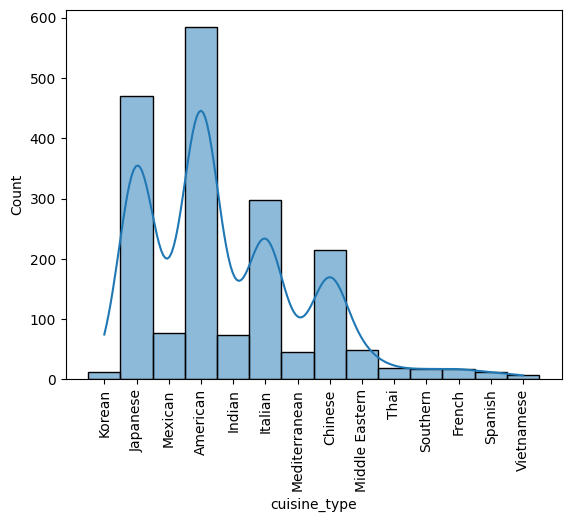

/tmp/ipython-input-3242002250.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  x.set_xticklabels(x.get_xticklabels(), rotation=90);


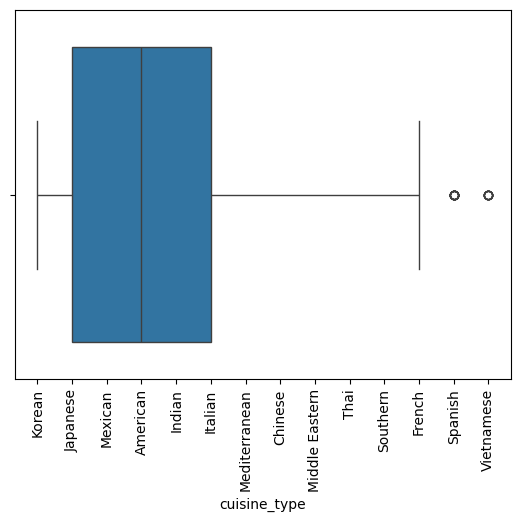

In [10]:
# Write the code here
ax = sns.histplot(data =foodhubdata,x='cuisine_type',kde= True);
ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
plt.show()
x = sns.boxplot(data = foodhubdata, x ='cuisine_type');
x.set_xticklabels(x.get_xticklabels(), rotation=90);
plt.show()


* The distribution of cuisine_type is right skewed
* There are few outliers which tells that some cuisine like Spanish and Vietnamese not many customers like it.
* Among all the cuisine_type, American Cusine count is high shows it is favourate cuisine.

### **Observations on Cost of the order**

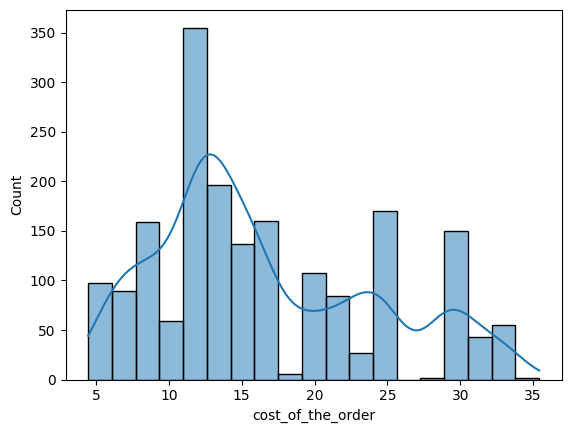

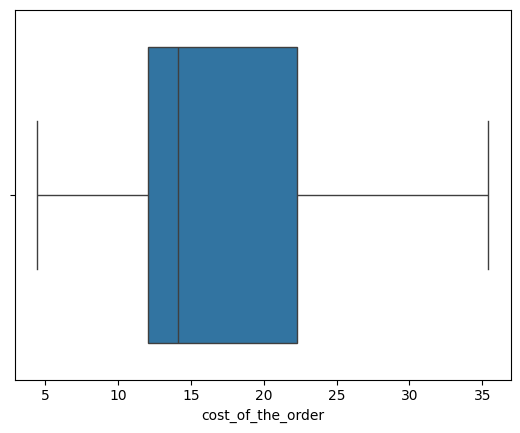

In [11]:
sns.histplot(data =foodhubdata,x='cost_of_the_order',kde= True);
plt.show()
sns.boxplot(data = foodhubdata, x ='cost_of_the_order');
plt.show()




*   There are no outliers for cost.
*   Most of the orders which are placed, costs beween 12 to 13 dollers for the customer.
*   It is right skewed.


### **Observations of Food Preparation Time**

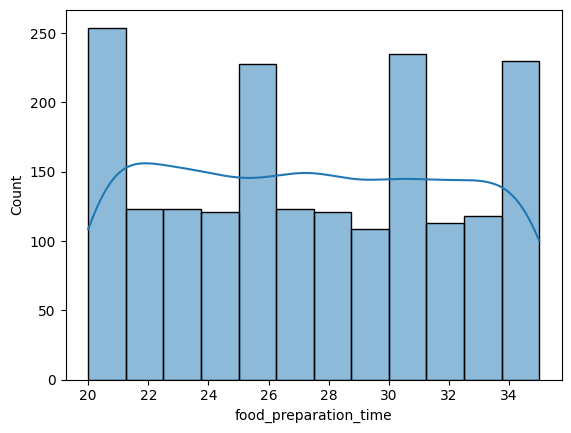

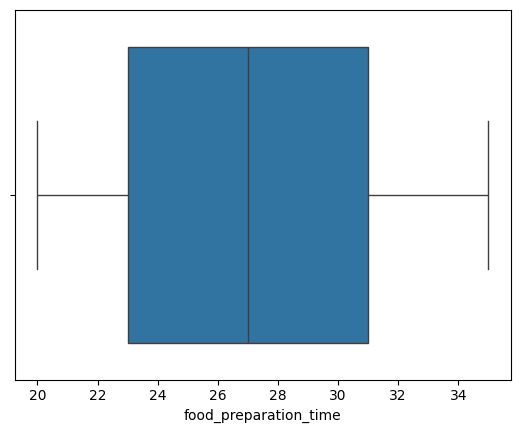

In [12]:
sns.histplot(data =foodhubdata,x='food_preparation_time',kde= True);
plt.show()
sns.boxplot(data = foodhubdata, x ='food_preparation_time');
plt.show()



*   The distribution of food preparation time is multi mode.
*   There are no outliers.
*   The mean and median are at the center.



### **Observations on Delivery Time**

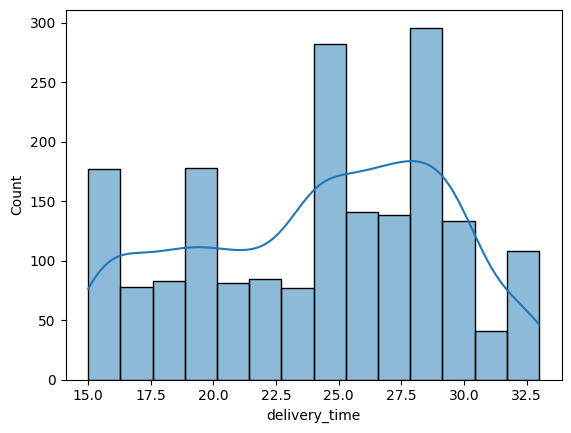

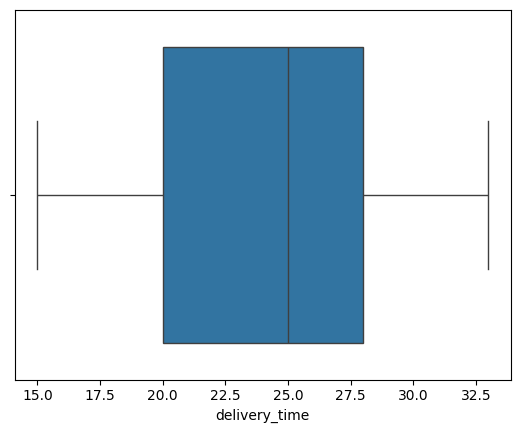

In [13]:
sns.histplot(data =foodhubdata,x='delivery_time', kde = True);
plt.show()
sns.boxplot(data = foodhubdata, x ='delivery_time');
plt.show()



*   Delivery time is left-skewed
*   There are no outliers for Delivery Time.
*   The average time for food delivery is about 25 min.




### **Oberservations on Ratings**

Let's check if there’s any specific pattern or relationship among customers who did not rate their orders.

In [14]:
# check if there is any specific relationship of rating with cost of the order with the Not given ratings.
foodhubdata[foodhubdata['rating']=='Not given'].groupby('delivery_time').rating.count().sort_values(ascending=False)

,rating
delivery_time,
28,60
29,60
24,60
30,55
26,54
27,52
16,43
25,41
19,39


In [15]:
# identify if there is any relation with delivery time and cuisine type for with the customer not rated the order.
foodhubdata[foodhubdata['rating']=='Not given'].groupby(['delivery_time','cuisine_type']).rating.count().sort_values(ascending=False)

,,rating
delivery_time,cuisine_type,
29,Japanese,25
28,American,21
24,American,19
26,Japanese,18
24,Japanese,17
...,...,...
31,Italian,1
32,Indian,1
31,Indian,1


In [16]:
#check if there is any specific cuisine for which customer didn't rated.
foodhubdata[foodhubdata['rating']=='Not given'].groupby('cuisine_type').rating.count()


,rating
cuisine_type,
American,216
Chinese,82
French,8
Indian,23
Italian,126
Japanese,197
Korean,4
Mediterranean,14
Mexican,29


In [17]:
#check customer not rated more on weekend or weekday
foodhubdata[foodhubdata['rating']=='Not given'].groupby('day_of_the_week').rating.count()

,rating
day_of_the_week,
Weekday,207
Weekend,529


**Observations:**



*   On weekend there are more orders which was not rated by customers.
*   American Cuisine is the highest no rated but on contradetory it got hightes rating as well.
*   With this analysis we cannot impute any ratings not rated orders.




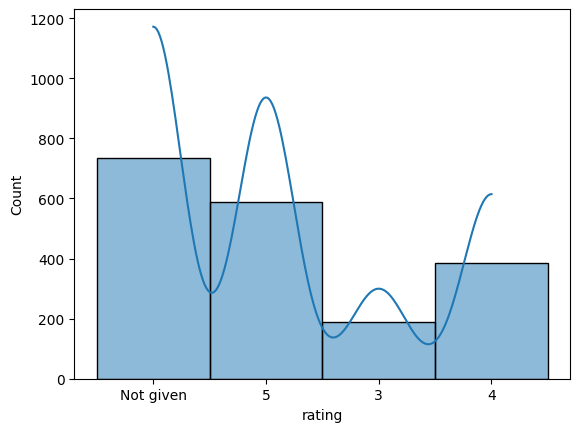

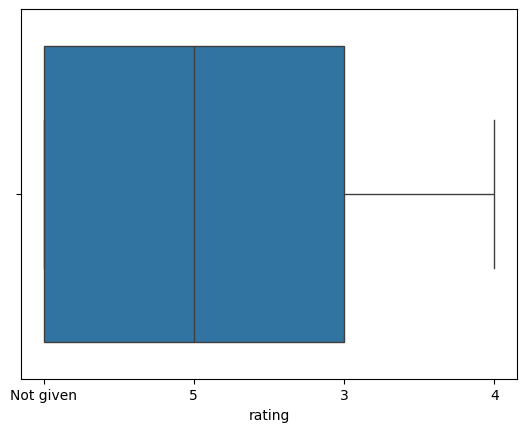

In [18]:
sns.histplot(data =foodhubdata,x='rating',kde= True);
plt.show()
sns.boxplot(data = foodhubdata, x ='rating');
plt.show()



*   The graph indicates that a significant number of orders have not been rated by customers.
*   There are no noticeable outliers in the data.
*   Among the rated orders, a rating of 5 is the most frequent.
*   The distribution of ratings is right-skewed.
*   An analysis of various parameters reveals that customers are less likely to provide ratings on weekends compared to weekdays.
*   Tried different ways to identify if there is any specific relation to order not rated with diffent parameter to reach to conclusion that shows why order not rated.



/tmp/ipython-input-2090905798.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  x.set_xticklabels(x.get_xticklabels(), rotation=90);


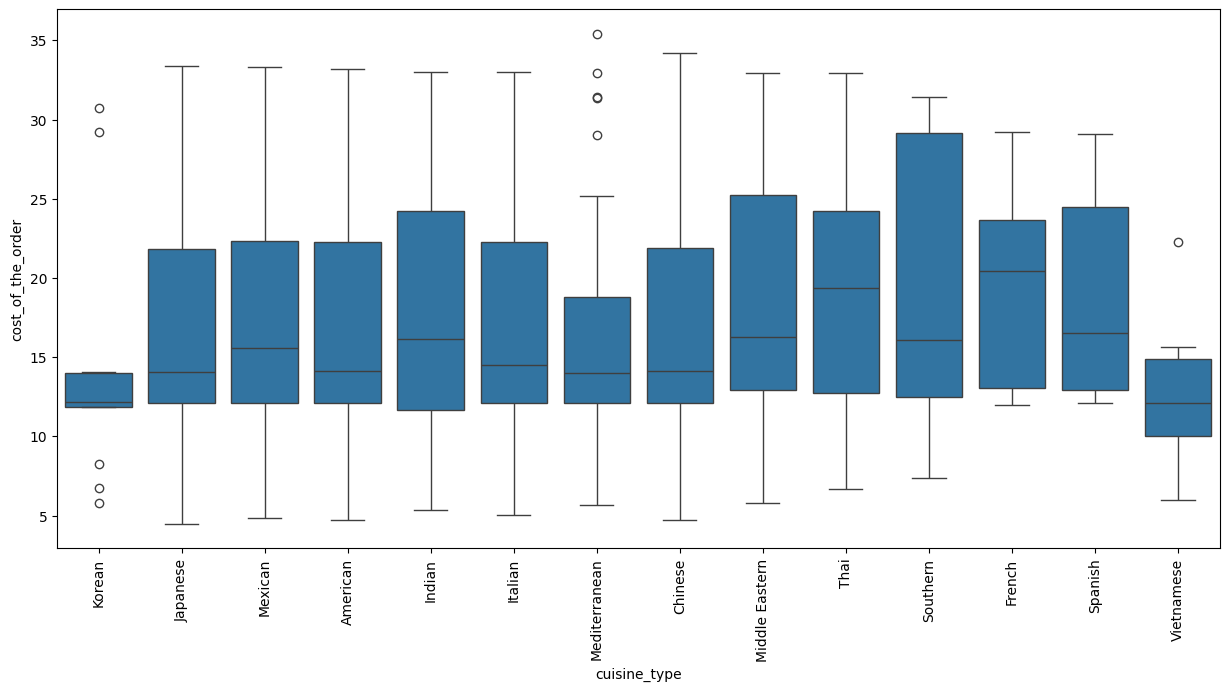

In [19]:
plt.figure(figsize=(15,7))
x= sns.boxplot(data = foodhubdata, x ='cuisine_type', y='cost_of_the_order');
x.set_xticklabels(x.get_xticklabels(), rotation=90);
plt.show();

**Observations:**



*   There are outliers for Mediterranean cuisine and Korean cuisine in terms of cost of order.






### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [20]:
# get the top 5 restaurants group by name and count the total number of orders that they received order by descending
foodhubdata.groupby('restaurant_name')['order_id'].count().sort_values(ascending=False).head()

,order_id
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:


*   Shake Shack received the hightest orders among all the restaurants.
*   The highest order received by the restaurant is 219.
*   Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Frid Chicken and Parm are the top 5 popular resturants.





### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [21]:
# grouby the day of the week and cusine type and calculate the total number of order.
foodhubdata.groupby(['day_of_the_week','cuisine_type'])['order_id'].count().sort_values(ascending=False).head()

day_of_the_week  cuisine_type
Weekend          American        415
                 Japanese        335
                 Italian         207
Weekday          American        169
Weekend          Chinese         163
Name: order_id, dtype: int64

#### Observations:



*   American Cuisine is the most popular cuisine on weekends.





### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [22]:
# get the orders which costs more than 20 dollarts and calculate the precentage
foodhubdata[foodhubdata['cost_of_the_order']>20].shape[0]/foodhubdata.shape[0]*100

29.24130663856691

#### Observations:

*   Approximatly 29% of orders costs more than 20 dollars.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [23]:
# Calculate the mean of the delivery time.
foodhubdata.delivery_time.mean()

np.float64(24.161749209694417)

#### Observations:

*   Avarage Delivery time for order is 24.16 min.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [24]:
# Get the customer id's who frequently order from restaurant to apply the discount.
foodhubdata.groupby('customer_id')['order_id'].count().sort_values(ascending=False).head(3)


,order_id
customer_id,
52832,13
47440,10
83287,9


#### Observations:



*   From the above result, customer id 52832, 47440 & 83287 are most frequent customers who should receive 20% discount vouchers.





### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


### **Correlation by HeatMap**

In [25]:
# selecting only numerical variable
num_var = foodhubdata.dtypes[foodhubdata.dtypes != 'object'].index


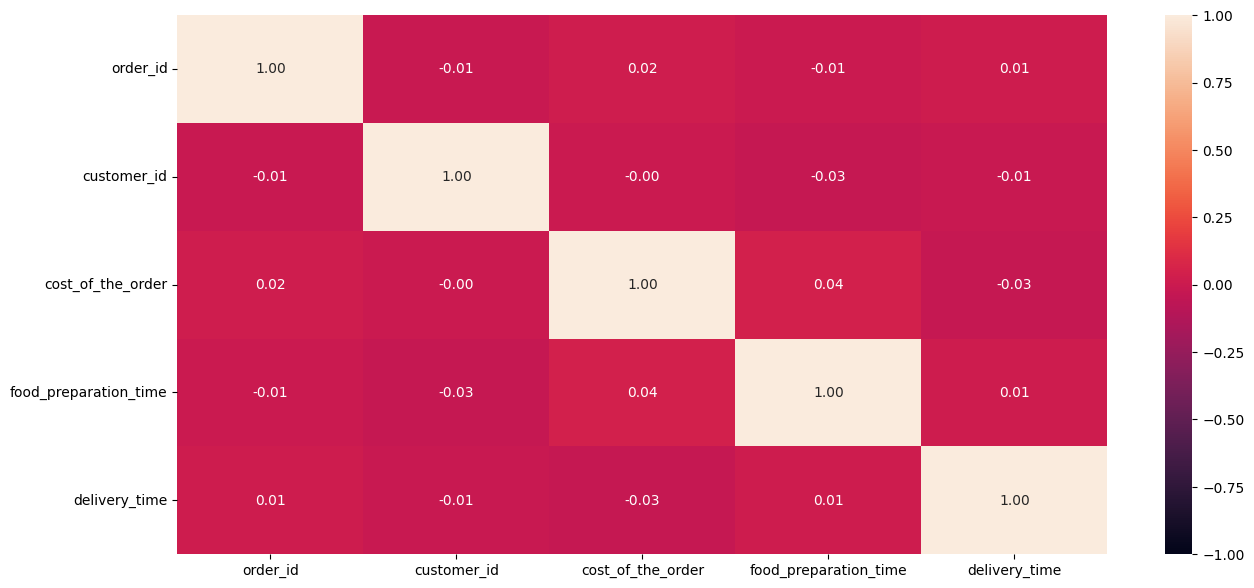

In [26]:
# check correlation between the numerical variable

corr= foodhubdata[num_var].corr(numeric_only= True)

#plot the heatmap
plt.figure(figsize = (15,7))
sns.heatmap(corr, annot = True, vmin = -1, vmax =1, fmt = '.2f')
plt.show()

**Observations:**



*   Food perparation time shows the highest correlation with Cost of the Order.
*   Delivery time would be negatively correlated with Cost of order, that means if the delivery time is more for the order which are less costly.



### **Byvariate Scatter Plots**

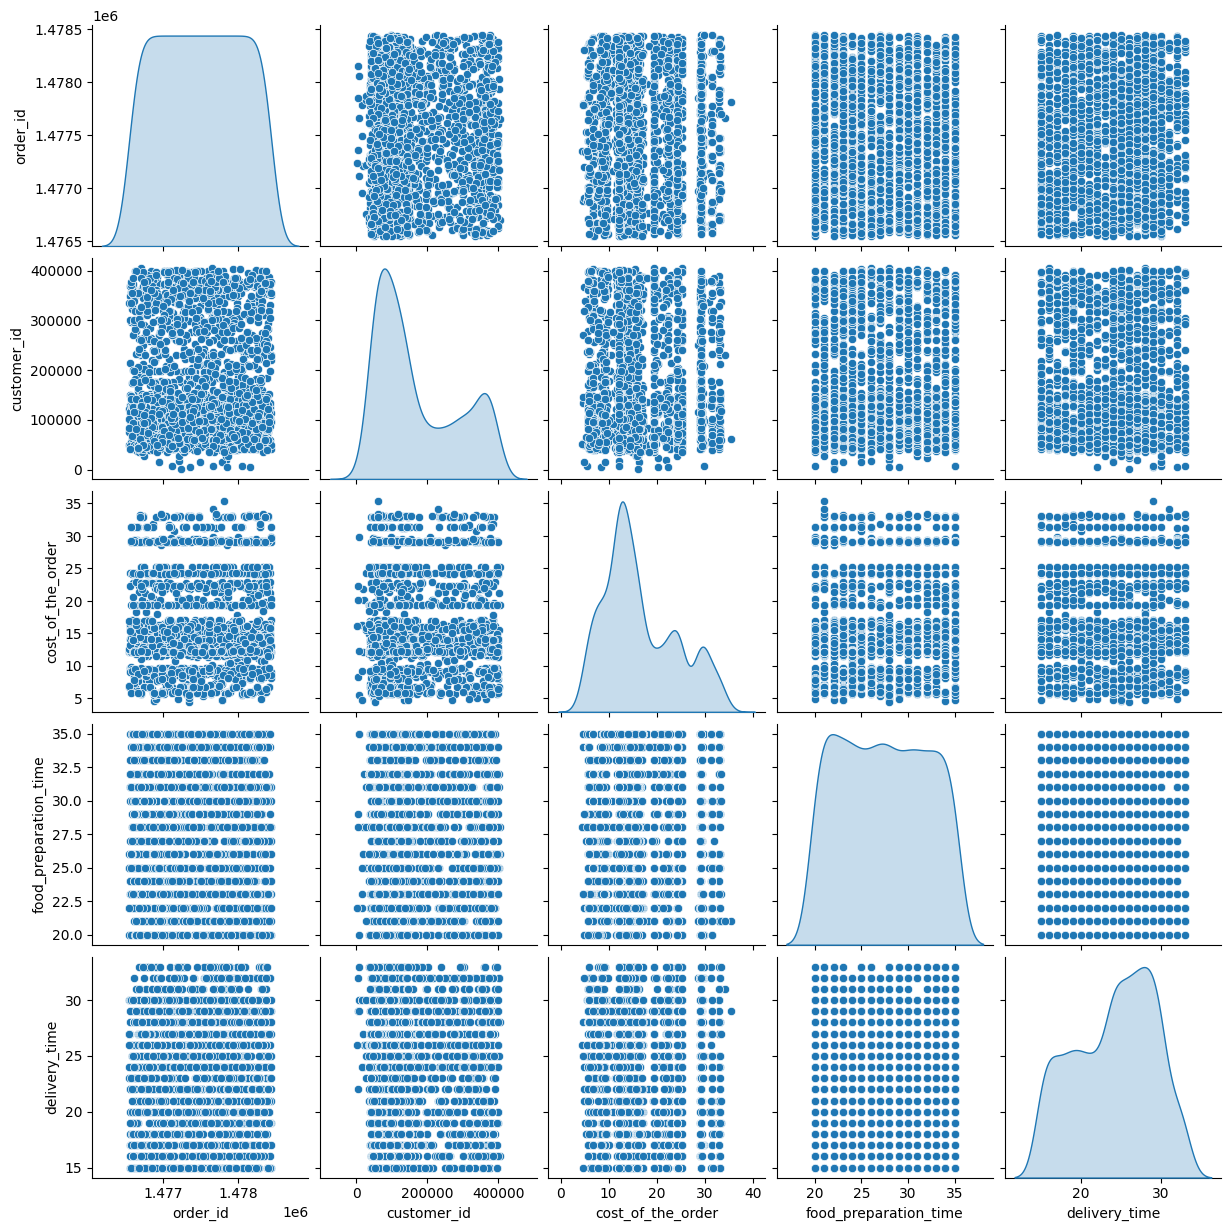

In [27]:
sns.pairplot(data= foodhubdata[num_var], diag_kind = 'kde')
plt.show()

**Observations:**

*   There are not much correlations between many variables.

/tmp/ipython-input-1954389530.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(data= foodhubdata, x='day_of_the_week', y ='food_preparation_time', ci=False,estimator= 'sum')


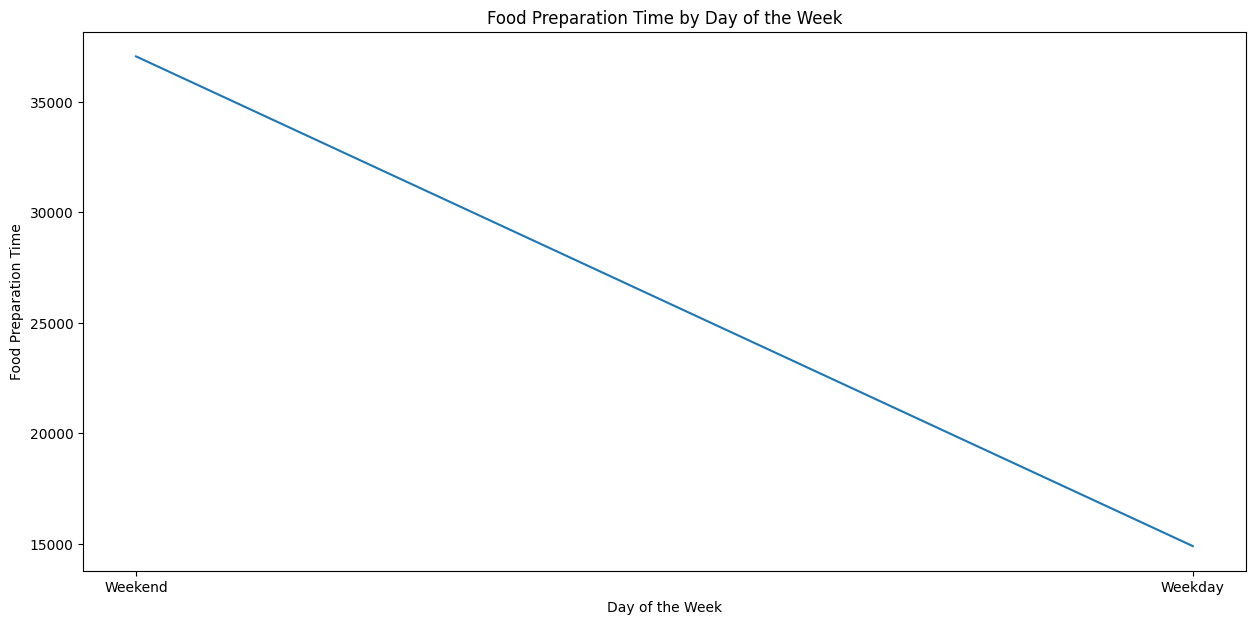

In [28]:
cats = foodhubdata.day_of_the_week.unique()

plt.figure(figsize=(15,7))
sns.lineplot(data= foodhubdata, x='day_of_the_week', y ='food_preparation_time', ci=False,estimator= 'sum')
plt.xlabel('Day of the Week')
plt.ylabel('Food Preparation Time')
plt.title('Food Preparation Time by Day of the Week')
plt.show()

 **Observation**

*   This is clear from graph that Food preperation time is high on weekend than weekday.

/tmp/ipython-input-1411229665.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(data= foodhubdata, x='day_of_the_week', y ='delivery_time', ci= False, estimator= sum, hue = 'cuisine_type');


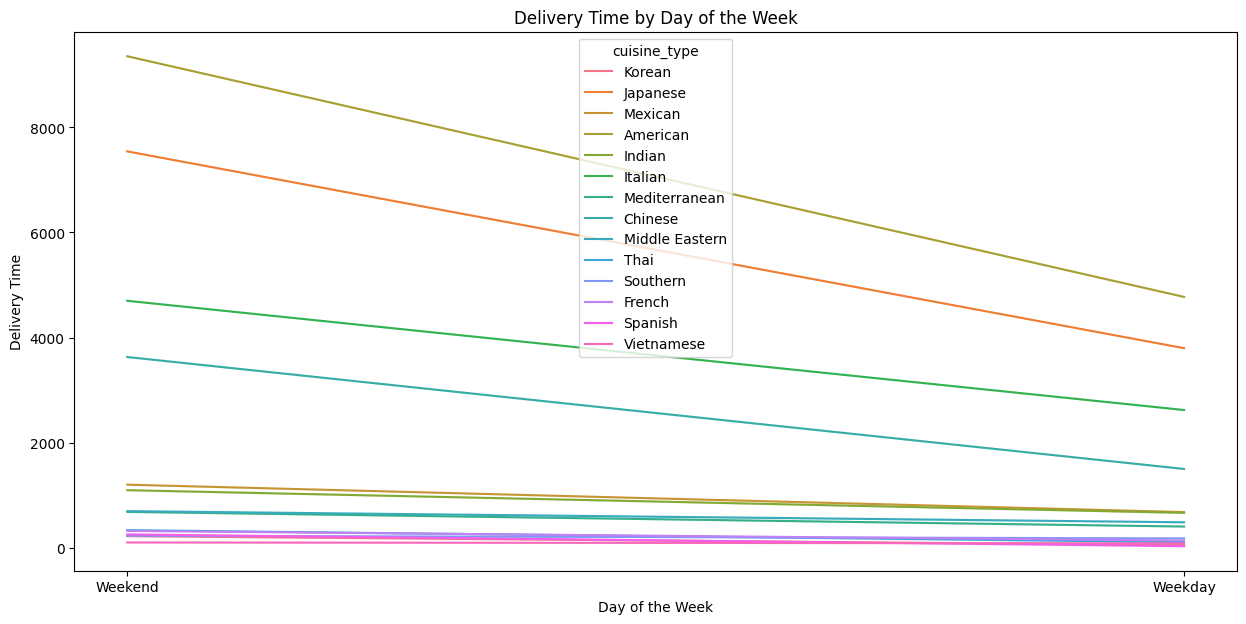

In [29]:
plt.figure(figsize=(15,7))
sns.lineplot(data= foodhubdata, x='day_of_the_week', y ='delivery_time', ci= False, estimator= sum, hue = 'cuisine_type');

plt.xlabel('Day of the Week')
plt.ylabel('Delivery Time')
plt.title('Delivery Time by Day of the Week')
plt.show()

**Observation**

*   For certain cuisine types, delivery times tend to be longer on weekends
compared to weekdays.
*   Except for four cuisines — American, Japanese, Italian, and Chinese — the delivery times remain relatively consistent between weekends and weekdays.

/tmp/ipython-input-2120284071.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(data= foodhubdata, x='day_of_the_week', y ='rating', ci=False);


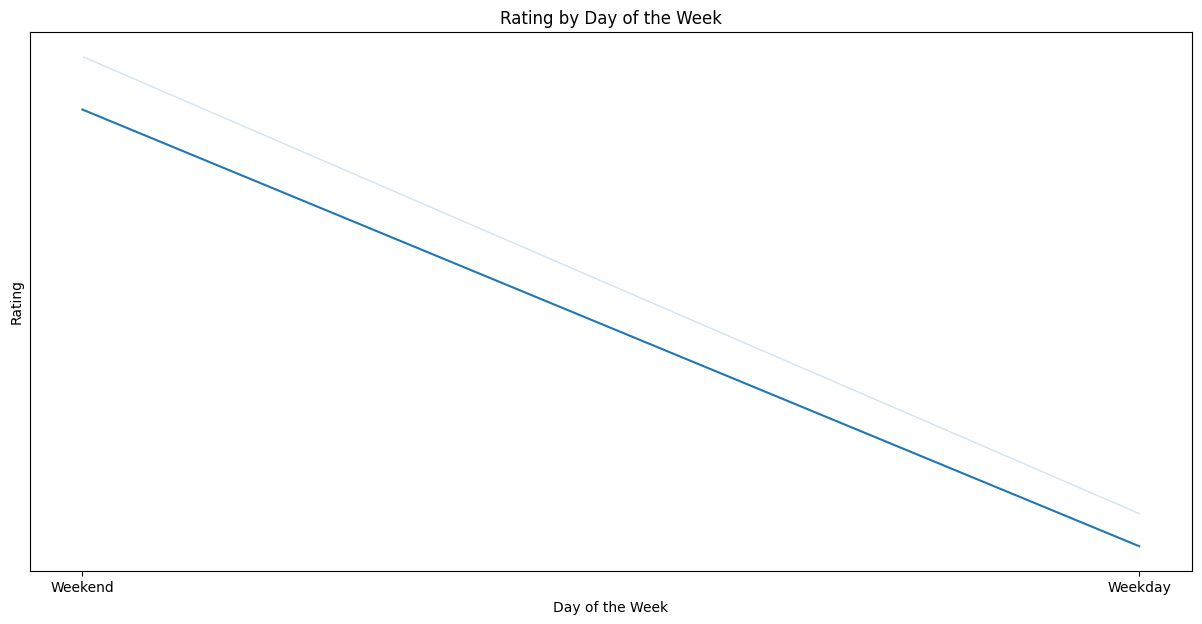

In [30]:
plt.figure(figsize=(15,7))
sns.lineplot(data= foodhubdata, x='day_of_the_week', y ='rating', ci=False);
plt.xlabel('Day of the Week')
plt.ylabel('Rating')
plt.title('Rating by Day of the Week')
plt.show()

**Observation**

*   The customer rated order more on Weekend than Weekday.



/tmp/ipython-input-3439603582.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(data= foodhubdata, x='day_of_the_week', y ='cost_of_the_order', ci=False,estimator= sum);


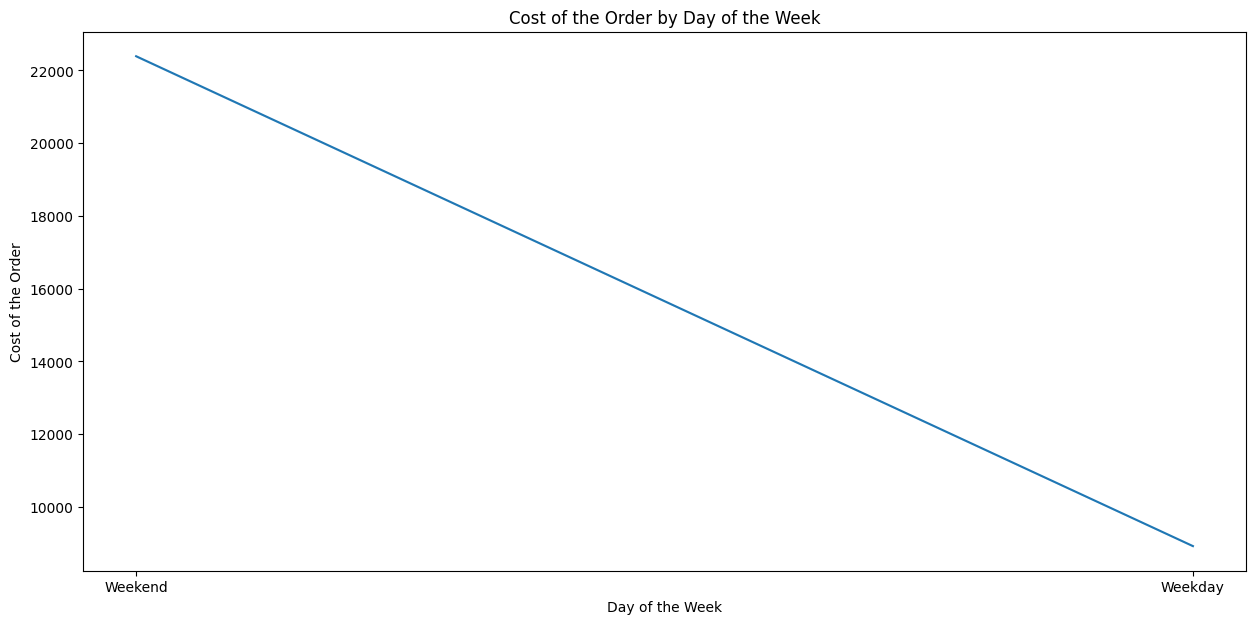

In [31]:
plt.figure(figsize=(15,7))
sns.lineplot(data= foodhubdata, x='day_of_the_week', y ='cost_of_the_order', ci=False,estimator= sum);
plt.xlabel('Day of the Week')
plt.ylabel('Cost of the Order')
plt.title('Cost of the Order by Day of the Week')
plt.show()

**Observations:**



*   During the weekend the cost of order is double than the weekday.




/tmp/ipython-input-164433812.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(data= foodhubdata, x='cuisine_type', y ='cost_of_the_order', ci=False,estimator= sum);


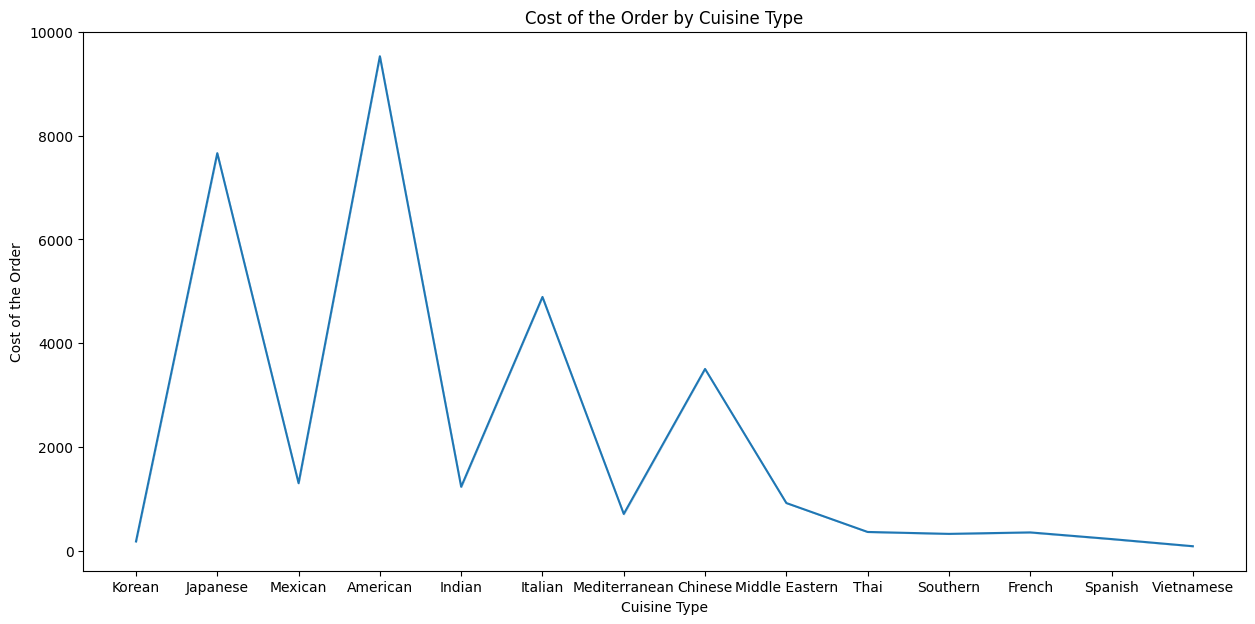

In [32]:
plt.figure(figsize=(15,7))
sns.lineplot(data= foodhubdata, x='cuisine_type', y ='cost_of_the_order', ci=False,estimator= sum);
plt.xlabel('Cuisine Type')
plt.ylabel('Cost of the Order')
plt.title('Cost of the Order by Cuisine Type')
plt.show()

 **Observations**:



*   Revenue generated by American Cuisine is highest among the other and the total revenue generated is around 9700.
*   The second hight revenue is from Japanese cuisine and it is around 8000 followed by italian cuisine.





/tmp/ipython-input-1167128958.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(data= foodhubdata, x='delivery_time', y ='cost_of_the_order', ci=False,estimator= sum);


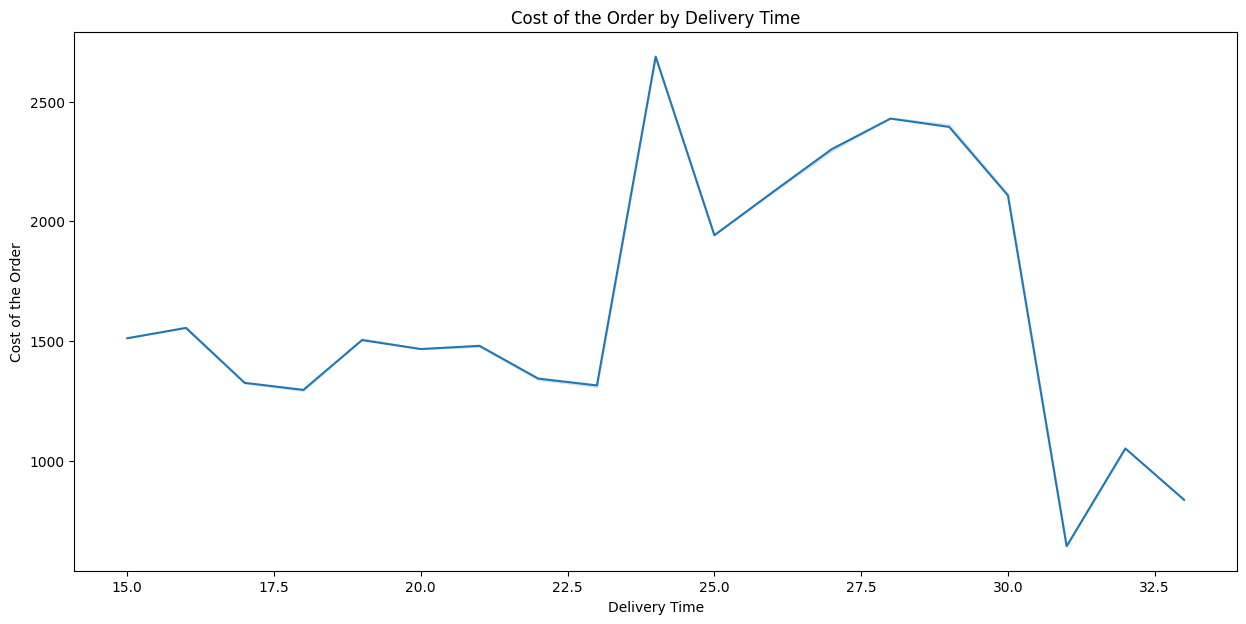

In [33]:
plt.figure(figsize=(15,7))
sns.lineplot(data= foodhubdata, x='delivery_time', y ='cost_of_the_order', ci=False,estimator= sum);
plt.xlabel('Delivery Time')
plt.ylabel('Cost of the Order')
plt.title('Cost of the Order by Delivery Time')
plt.show()

**Observations:**


*   There is sharp fall in the cost of order when the delivery time is going beyond 30 min.




/tmp/ipython-input-3453940165.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(data= foodhubdata, x='cost_of_the_order', y ='food_preparation_time', ci=False,estimator= sum);


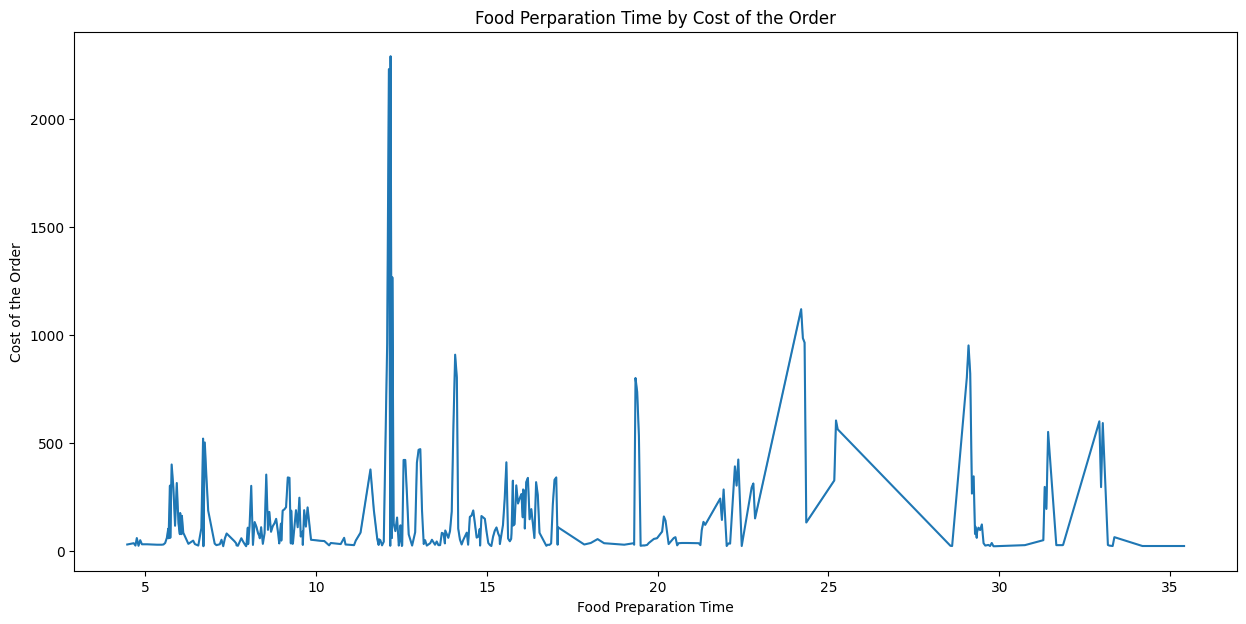

In [34]:
plt.figure(figsize=(15,7))
sns.lineplot(data= foodhubdata, x='cost_of_the_order', y ='food_preparation_time', ci=False,estimator= sum);
plt.xlabel('Food Preparation Time')
plt.ylabel('Cost of the Order')
plt.title('Food Perparation Time by Cost of the Order')
plt.show()

**Observations:**



*   There is sharp increase in the cost when the food preparation time is between 12 to 13 min.




/tmp/ipython-input-3663315256.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(data= foodhubdata, x='day_of_the_week', y ='cuisine_type', ci=False,estimator= sum,hue = 'cuisine_type');


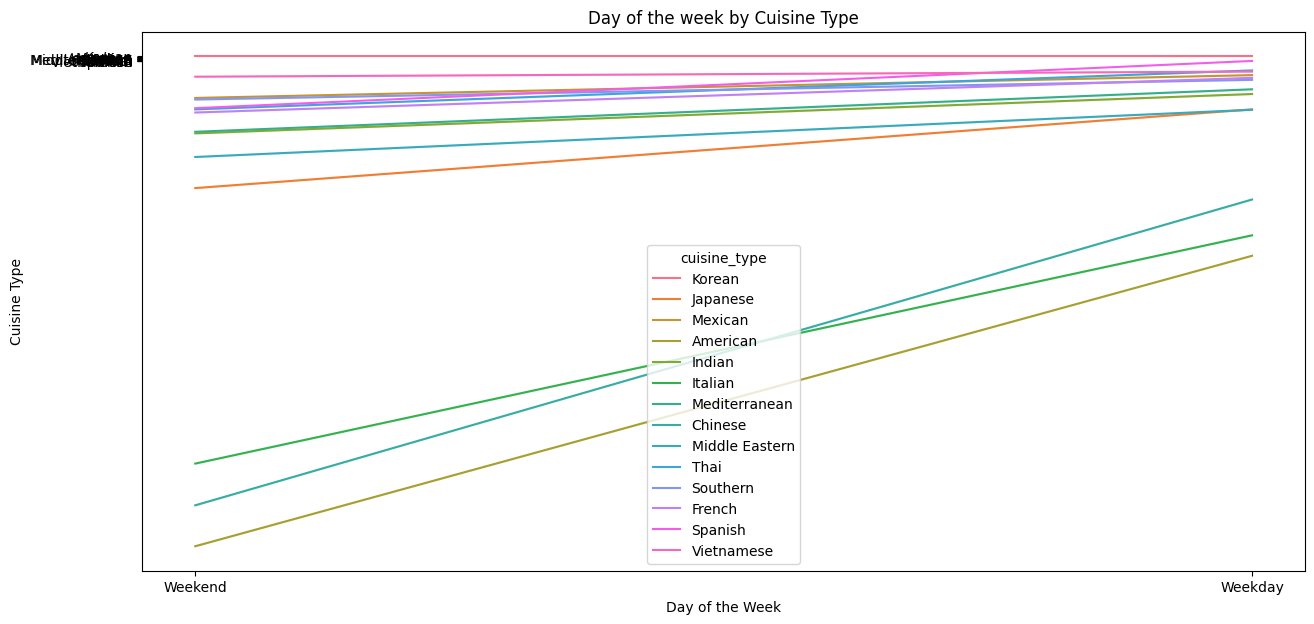

In [35]:
plt.figure(figsize=(15,7))
sns.lineplot(data= foodhubdata, x='day_of_the_week', y ='cuisine_type', ci=False,estimator= sum,hue = 'cuisine_type');
plt.xlabel('Day of the Week')
plt.ylabel('Cuisine Type')
plt.title('Day of the week by Cuisine Type')
plt.show()

**Observations:**


*   Demand for American Cuisine increases over weekday followed by Italian.
*   For few Cusines the demand on weekend and weekday is same, like Vietnamese, Spanish etc. cuisines.



### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [36]:
# Write the code here

#create new data frame without Not given rating
foodhubdata_new= foodhubdata[foodhubdata['rating']!='Not given']

In [37]:
#since there are only numerical values in rating column change the data type to numeric to calculate the mean
foodhubdata_new['rating'] = pd.to_numeric(foodhubdata_new['rating'])

/tmp/ipython-input-2263222046.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foodhubdata_new['rating'] = pd.to_numeric(foodhubdata_new['rating'])


In [38]:
foodhubdata_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1162 entries, 2 to 1896
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1162 non-null   int64  
 1   customer_id            1162 non-null   int64  
 2   restaurant_name        1162 non-null   object 
 3   cuisine_type           1162 non-null   object 
 4   cost_of_the_order      1162 non-null   float64
 5   day_of_the_week        1162 non-null   object 
 6   rating                 1162 non-null   int64  
 7   food_preparation_time  1162 non-null   int64  
 8   delivery_time          1162 non-null   int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 90.8+ KB


/tmp/ipython-input-2340887690.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(data= foodhubdata_new, x='day_of_the_week', y ='rating', ci=False,estimator=sum,hue='rating');


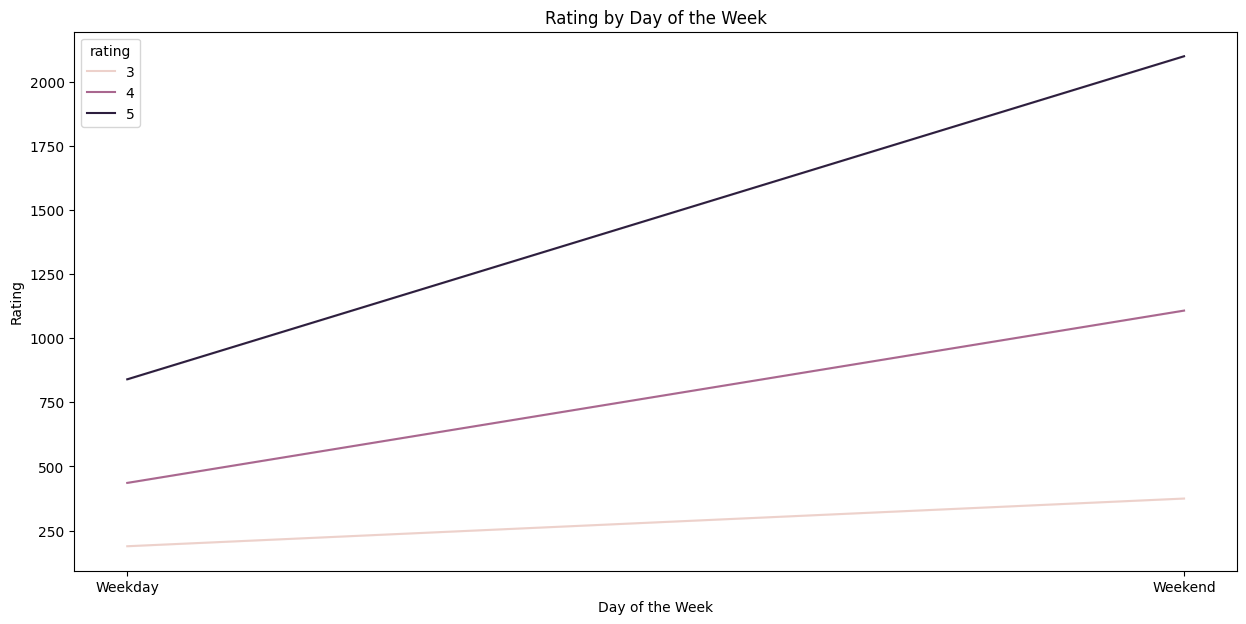

In [39]:
plt.figure(figsize=(15,7))
sns.lineplot(data= foodhubdata_new, x='day_of_the_week', y ='rating', ci=False,estimator=sum,hue='rating');
plt.xlabel('Day of the Week')
plt.ylabel('Rating')
plt.title('Rating by Day of the Week')
plt.show()

In [40]:
#get the unique restaurant who got ratings more than 50 and avrange rating more than 4
highratedrestaurant = foodhubdata_new.groupby('restaurant_name').filter(lambda x: x['rating'].count() > 50 and x['rating'].mean() > 4).restaurant_name.unique()

#print the restaurant name and there averate ratings.
for restaurant in highratedrestaurant:
  print('Restaurant Name',restaurant,"Average rating",foodhubdata_new[foodhubdata_new['restaurant_name'] ==restaurant].rating.mean())


Restaurant Name Blue Ribbon Fried Chicken Average rating 4.328125
Restaurant Name Shake Shack Average rating 4.2781954887218046
Restaurant Name Blue Ribbon Sushi Average rating 4.219178082191781
Restaurant Name The Meatball Shop Average rating 4.511904761904762


#### Observations:

*    We can see from the result that there are 4 reastaurant named "Blue Ribbon Fried Chicken", "Shake Shack", "Blue Ribbon Sushi", "The Meatball Shop" whos number of ratings are more than 50 and average rating is more than 4

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [41]:
# intialize the revenue variable
revenue = 0

#iterate over each row of the dataset and calculate revenue based on the cost of the order
for i in range(foodhubdata.shape[0]):
  # 25% charge for order cost more than 20 dollars
  if foodhubdata.loc[i,'cost_of_the_order'] > 20:
    revenue += foodhubdata.loc[i,'cost_of_the_order'] * 0.25
  # 15% charges for order cost more than 5 dollers
  elif foodhubdata.loc[i,'cost_of_the_order'] > 5:
    revenue += foodhubdata.loc[i,'cost_of_the_order'] * 0.15


print('The net revenue generated by the company across all orders is',revenue)

The net revenue generated by the company across all orders is 6166.302999999994


#### Observations:

*   It is clearly see that the net revenue generated by the company across all order is 6166.30 dollars

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [42]:
#add total time column to the dataset to analyze total time for each order
foodhubdata['total_time'] = foodhubdata['food_preparation_time'] + foodhubdata['delivery_time']

In [43]:
#number of order whose total time is more than 60
timeconsumingorders = foodhubdata[foodhubdata['total_time']>60].value_counts().shape[0]

#total number of orders in the dataset
totalnumberoforders = foodhubdata.shape[0]

print('The percentage of orders take more than 60 minutes to get delivered from the time the order is placed is',timeconsumingorders/totalnumberoforders*100)



The percentage of orders take more than 60 minutes to get delivered from the time the order is placed is 10.537407797681771


#### Observations:



*   There are around 10.53% of total orders which is taking more than 60 min to prepare and deliver food to the customers order.





### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [44]:
# ge the average delivery time on day of the week.
foodhubdata.groupby('day_of_the_week')['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations:


*   Delivery time on Weekday is 28.34 min and on weekend it is 22.47 min
*   Delivery time on Weekday is more than Weekend.





### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:

We analyzed a dataset containing approximately 1,900 online food orders. The analysis considered various parameters such as cuisine type, restaurant name, order cost, delivery time, and more.
From the analysis, we concluded the following:
*  American cuisine is the most popular among all cuisine types.
*  Average delivery time is higher on weekdays compared to weekends.
*  Preparation time tends to increase with higher-order costs.
*  The average delivery time across both weekends and weekdays is 24.12 minutes.
*  Approximately 29% of orders cost more than $20.
*  The top five most popular restaurants are Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, and Parm.

### Recommendations:

*  American cuisine emerges as the most preferred choice among customers.
*  A higher proportion of unrated orders are observed during weekends compared to weekdays.
*  Restaurants specializing in American cuisine receive the highest volume of orders.
*  Approximately 10.53% of total orders require over 60 minutes for preparation and delivery.
*  Average delivery time on weekday is 28.34 which is more than the Weekend, as the number of orders are more in weekday, it is good idea to reduce this delivery time.
*  Number of orders are less in weekend, any promotions for weekend can increase the number of orders.


---